# Демонстрация MoLFormer


# Содержание ноутбука

1. Введение и условная задача
2. Установка зависимостей и загрузка моделей
3. Краткая архитектурная справка (где говорить об архитектуре)
4. Получение эмбеддингов и визуализация (heatmap, PCA)
5. Token-level анализ и attention (пояснения)
6. Генерация SMILES — исследование влияния temperature
7. Сводка: преимущества / ограничения / выводы

---

# 1. Введение и условная задача

**Условная задача демонстрации:**


> Допустим, у нас есть целевая молекула — *aspirin*. Задача: показать, как модель MoLFormer может
> - получить плотное представление молекулы (эмбеддинг),
> - найти похожие молекулы в латентном пространстве,
> - сгенерировать кандидаты (продолжения SMILES) для возможных аналогов.


# 2. Установка зависимостей и загрузка моделей

In [1]:
# Импорт и базовый setup
import sys
import os
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from tqdm.auto import trange
import matplotlib.pyplot as plt
from IPython.display import display

# Проверка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Указываем модели (чекпоинты, используемые в демо)
EMB_MODEL = 'ibm-research/MoLFormer-XL-both-10pct'
GEN_MODEL = 'ibm-research/GP-MoLFormer-Uniq'

# Загрузка токенизатора и моделей (это занимает время)
print('Loading tokenizer and embedding model...')
tokenizer = AutoTokenizer.from_pretrained(EMB_MODEL, trust_remote_code=True)
emb_model = AutoModel.from_pretrained(EMB_MODEL, trust_remote_code=True).to(device)
emb_model.eval()

print('Loading generative model...')
gen_model = AutoModelForCausalLM.from_pretrained(GEN_MODEL, trust_remote_code=True).to(device)
gen_model.eval()

/home/pingvin/miniconda3/envs/gp-molformer/lib/python3.10/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/home/pingvin/miniconda3/envs/gp-molformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Loading tokenizer and embedding model...
Loading generative model...


MolformerForCausalLM(
  (molformer): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
         

---

# 3. Краткая архитектурная справка

**Ключевые пункты, которые нужно проговорить:**

- Модель основана на архитектуре *Transformer* (Vaswani et al.) — использует self-attention. Для SMILES используются либо encoder-style (вытягивание представления по токенам) либо causal LM (для генерации).
- Токенизация SMILES: модель оперирует токенами, соответствующими атомам/связям/скобкам/цифрам замкнутых колец.
- Для эмбеддинга молекулы: получаем `last_hidden_state` (последний слой), агрегируем (например, mean pooling) → получаем вектор молекулы.
- Для генерации: causal LM предсказывает следующий токен в SMILES; сэмплинг управляется параметрами `temperature`, `top_p`, `top_k`.

**Где в ноутбуке это демонстрируется:**
- Token-level PCA и L2-norm (появление значимых токенов);
- Attention heatmap — показывает локальные зависимости;
- Генерация — демонстрирует causal LM в действии.

---

# 4. Подготовка данных для демонстрации

In [2]:
# Подавление предупреждений
import warnings
from transformers import logging as transformers_logging

# Отключаем конкретное предупреждение про attention
warnings.filterwarnings('ignore', message='Outputting attentions in linear attention')

# Устанавливаем минимальный уровень логирования для transformers
transformers_logging.set_verbosity_error()

# Если хотите видеть только ошибки, но не предупреждения
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

print("Предупреждения от transformers подавлены")

Предупреждения от transformers подавлены


In [3]:
# Функция-обертка для подавления вывода
from io import StringIO
from contextlib import redirect_stderr

# Набор молекул для примера
molecules = {
    'aspirin': 'CC(=O)OC1=CC=CC=C1C(=O)O',
    'salicylic_acid': 'OC1=CC=CC=C1C(=O)O',
    'ibuprofen': 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
    'paracetamol': 'CC(=O)NC1=CC=C(O)C=C1',
    'benzene': 'c1ccccc1',
    'ethanol': 'CCO'
}


def get_embedding_and_tokens_v2(smiles, agg='mean'):
    with redirect_stderr(StringIO()):  # Перенаправляем stderr в никуда
        inputs = tokenizer(smiles, return_tensors='pt').to(device)
        input_ids = inputs['input_ids'].squeeze(0).cpu().tolist()
        tokens = tokenizer.convert_ids_to_tokens(input_ids)
        
        with torch.no_grad():
            outputs = emb_model(**inputs, output_attentions=True)
        
        last_hidden = outputs.last_hidden_state.squeeze(0).cpu().numpy()
        
        if last_hidden.shape[0] != len(tokens):
            tokens = tokens[: last_hidden.shape[0]]
            
        emb = last_hidden.mean(axis=0) if agg=='mean' else last_hidden[0]
        attentions = outputs.attentions if hasattr(outputs, 'attentions') else None
        
        return emb, last_hidden, tokens, attentions

# Сбор эмбеддингов для набора
print("Вычисляем эмбеддинги для демо-молекул...")
embeddings = {}
token_info = {}
attentions_info = {}

for name, smi in molecules.items():
    emb, token_embs, tokens, atts = get_embedding_and_tokens_v2(smi)
    embeddings[name] = emb
    token_info[name] = {'tokens': tokens, 'token_embs': token_embs}
    attentions_info[name] = atts

Вычисляем эмбеддинги для демо-молекул...


# 5. Визуализация: heatmap косинусной схожести

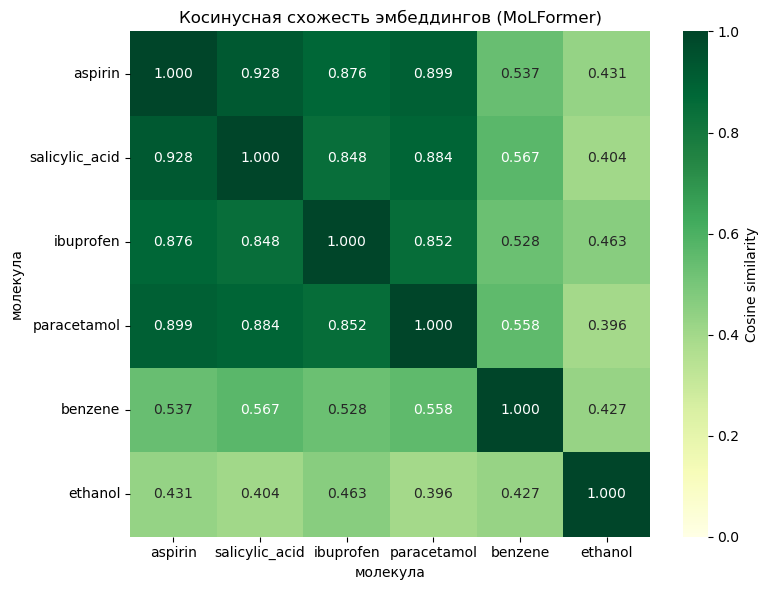

Пояснение: чем ближе значение к 1 (темно-зеленый), тем ближе молекулы в латентном пространстве.
Белый цвет соответствует значению 0 (ортогональные вектора).


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

names = list(embeddings.keys())
emb_matrix = np.vstack([embeddings[n] for n in names])
sim_matrix = cosine_similarity(emb_matrix)

# Альтернатива: использование встроенной схемы с зеленым
plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, 
            xticklabels=names, 
            yticklabels=names, 
            annot=True, 
            fmt='.3f', 
            cmap='YlGn',  # Желто-зеленая схема (от светлого к темно-зеленому)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Cosine similarity'})
plt.title('Косинусная схожесть эмбеддингов (MoLFormer)')
plt.xlabel('молекула')
plt.ylabel('молекула')
plt.tight_layout()
plt.show()

print('Пояснение: чем ближе значение к 1 (темно-зеленый), тем ближе молекулы в латентном пространстве.')
print('Белый цвет соответствует значению 0 (ортогональные вектора).')

# 6. Визуализация: PCA 2D

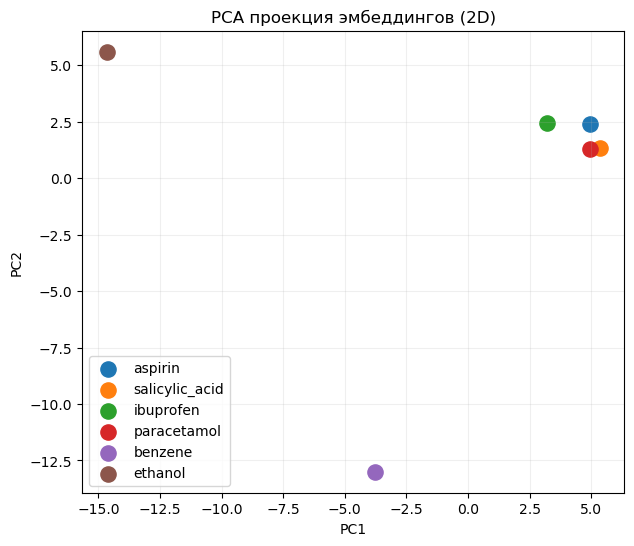

Пояснение (PCA): 
— Точки в 2D представлении латентного пространства.- Молекулы, близкие друг к другу, вероятно, имеют схожие структурные признаки 
— модель выучила полезные представления.


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(emb_matrix)

plt.figure(figsize=(7,6))
colors = plt.get_cmap('tab10')
for i,name in enumerate(names):
    plt.scatter(coords[i,0], coords[i,1], s=120, color=colors(i%10), label=name)
plt.title('PCA проекция эмбеддингов (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print('Пояснение (PCA): \n— Точки в 2D представлении латентного пространства.- Молекулы, близкие друг к другу, вероятно, имеют схожие структурные признаки \n— модель выучила полезные представления.')

# 7. Визуализация самого аспирина

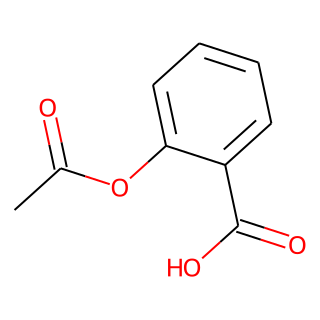

In [6]:
aspirin_smiles = molecules['aspirin']
asp_mol = Chem.MolFromSmiles(aspirin_smiles)
# Конвертируем в изображение и показываем
img = Draw.MolToImage(asp_mol, size=(320,320))
display(img)

# 8. Token-level: PCA токенов + L2-норма эмбеддингов токенов

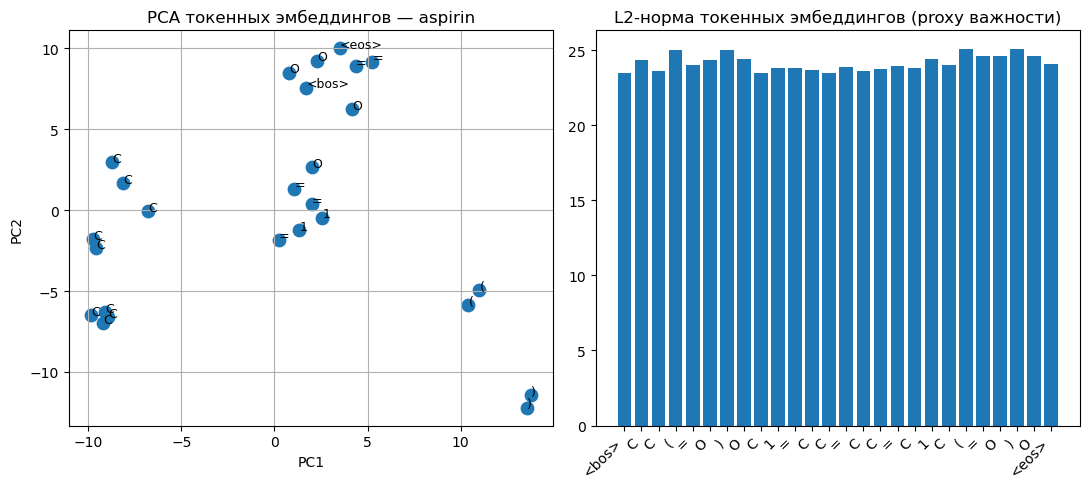

Пояснение (token-level):
- PCA токенов показывает распределение локальных фрагментов.
- L2-норма дает простую эвристику, какие токены (фрагменты) вносят больший вклад в эмбеддинг молекулы.


In [7]:
inspect = 'aspirin'
tokens = token_info[inspect]['tokens']
token_embs = token_info[inspect]['token_embs']

pca_tok = PCA(n_components=2)
tok_coords = pca_tok.fit_transform(token_embs)

plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.scatter(tok_coords[:,0], tok_coords[:,1], s=80)
for i,t in enumerate(tokens):
    plt.text(tok_coords[i,0]+0.01, tok_coords[i,1]+0.01, t, fontsize=9)
plt.title(f'PCA токенных эмбеддингов — {inspect}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()

plt.subplot(1,2,2)
norms = np.linalg.norm(token_embs, axis=1)
plt.bar(range(len(norms)), norms)
plt.xticks(range(len(norms)), tokens, rotation=45, ha='right')
plt.title('L2-норма токенных эмбеддингов (proxy важности)')
plt.tight_layout()
plt.show()

print('Пояснение (token-level):\n- PCA токенов показывает распределение локальных фрагментов.\n- L2-норма дает простую эвристику, какие токены (фрагменты) вносят больший вклад в эмбеддинг молекулы.')

# 9. Attention heatmap

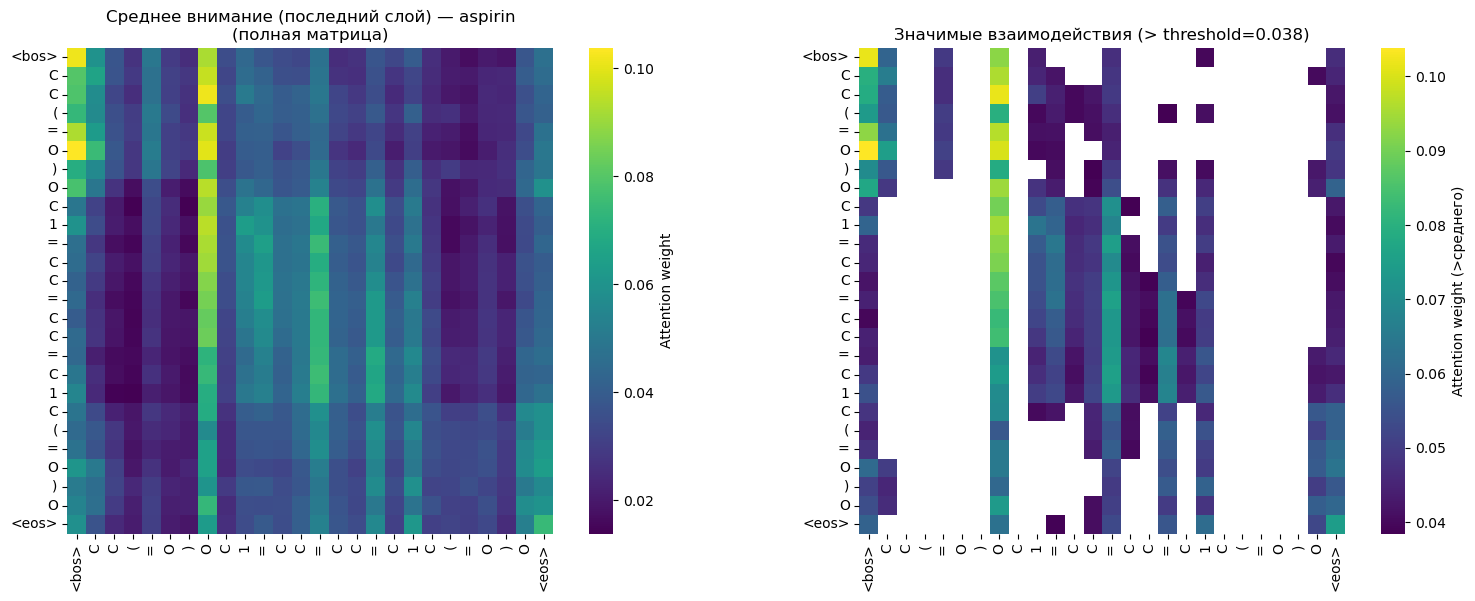


АНАЛИЗ ATTENTION ПАТТЕРНОВ

Топ-5 самых сильных взаимодействий:
   O -> <bos>: 0.1038
   C -> O: 0.1017
   <bos> -> <bos>: 0.1016
   O -> O: 0.0998
   = -> O: 0.0965


In [13]:
# Улучшенная визуализация attention для aspirin
atts = attentions_info.get('aspirin')
if atts is not None:
    # Берем последний слой
    last_layer_att = atts[-1].squeeze(0).cpu().numpy()  # (heads, seq, seq)
    
    # Усредняем по всем головам
    avg_att = last_layer_att.mean(axis=0)
    
    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Полная heatmap
    sns.heatmap(avg_att, 
                xticklabels=tokens, 
                yticklabels=tokens, 
                cmap='viridis', 
                square=True,
                ax=axes[0],
                cbar_kws={'label': 'Attention weight'})
    axes[0].set_title('Среднее внимание (последний слой) — aspirin\n(полная матрица)', fontsize=12)

    
    # 2. Только значимые взаимодействия (> среднего)
    threshold = np.mean(avg_att)
    mask = avg_att < threshold
    sns.heatmap(avg_att, 
                xticklabels=tokens, 
                yticklabels=tokens, 
                cmap='viridis', 
                square=True,
                ax=axes[1],
                mask=mask,
                cbar_kws={'label': 'Attention weight (>среднего)'})
    axes[1].set_title(f'Значимые взаимодействия (> threshold={threshold:.3f})', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Анализ паттернов внимания
    print('\n' + '='*60)
    print('АНАЛИЗ ATTENTION ПАТТЕРНОВ')
    print('='*60)
    
    # Самые сильные взаимодействия
    print('\nТоп-5 самых сильных взаимодействий:')
    flat_indices = np.argsort(avg_att.flatten())[-5:][::-1]
    for idx in flat_indices:
        i, j = idx // avg_att.shape[1], idx % avg_att.shape[1]
        print(f'   {tokens[i]} -> {tokens[j]}: {avg_att[i, j]:.4f}')

# 10. Генерация SMILES

In [9]:
# Функция генерации
def generate_smiles(fragment, batch_size=20, temperature=1.0, max_length=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if max_length is None:
        try:
            max_length = gen_model.config.max_position_embeddings
        except Exception:
            max_length = 256
    inputs = tokenizer(fragment, return_tensors='pt').to(device)
    with torch.no_grad():
        out = gen_model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            max_length=max_length,
            num_return_sequences=batch_size,
            pad_token_id=tokenizer.eos_token_id
        ).cpu()
    decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
    cleaned = [d.strip().split()[0] for d in decoded if isinstance(d, str) and d.strip()]
    return cleaned

In [22]:
fragment = 'CC(=O)OC1=CC'

# Генерируем на разных температурах
temps = [0.2, 0.7, 1.5]
results = {}
for t in temps:
    gen = generate_smiles(fragment, batch_size=500, temperature=t, seed=42)
    valid = [s for s in gen if Chem.MolFromSmiles(s)]
    results[t] = {'raw': gen, 'valid': valid}
    print(f'Temp={t}: generated={len(gen)}, valid={len(valid)}, unique_valid={len(set(valid))}')

print('\nПояснение (генерация):')
print('- Низкая температура → более детерминированные (менее разнообразные) продолжения.')
print('- Высокая температура → больше разнообразия, но и больше невалидных SMILES.')

Temp=0.2: generated=500, valid=500, unique_valid=14
Temp=0.7: generated=500, valid=500, unique_valid=215
Temp=1.5: generated=500, valid=440, unique_valid=361

Пояснение (генерация):
- Низкая температура → более детерминированные (менее разнообразные) продолжения.
- Высокая температура → больше разнообразия, но и больше невалидных SMILES.


[15:33:03] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 14 15 16 17 18
[15:33:03] WARNING: not removing hydrogen atom without neighbors
[15:33:03] WARNING: not removing hydrogen atom without neighbors
[15:33:03] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 15
[15:33:03] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 18 23 24 25 26 27 30 31 33
[15:33:03] SMILES Parse Error: unclosed ring for input: 'CC(=O)OC1=CC=N'
[15:33:03] SMILES Parse Error: unclosed ring for input: 'CC(=O)OC1=CCOc2c3nc4[nH+]c(nc5c4[n-]c(nc6nc(nc2[n-]3)[n-]6)-c2ccc(cc2-6)N1C1NC2=[N+](N3C12c1ccccc2C(=O)c2ccccc21)c1ccccc1-5)OC(C(O)c1ccccc1)[n+]1c3ccccc21.[OH3+]'
[15:33:03] Explicit valence for atom # 18 C, 5, is greater than permitted
[15:33:03] Explicit valence for atom # 8 O, 3, is greater than permitted
[15:33:03] Explicit valence for atom # 21 N, 4, is greater than permitted
[15:33:03] Explicit valence for atom # 14 C, 5, is greater than permitted
[15:33:03] SMILES Parse Error: unclosed ring fo

# 11. Анализ сгенерированных кандидатов и визуализация 

[15:33:14] WARNING: not removing hydrogen atom without neighbors
[15:33:14] WARNING: not removing hydrogen atom without neighbors
[15:33:14] WARNING: not removing hydrogen atom without neighbors
[15:33:14] WARNING: not removing hydrogen atom without neighbors
[15:33:16] WARNING: not removing hydrogen atom without neighbors
[15:33:16] WARNING: not removing hydrogen atom without neighbors
[15:33:16] WARNING: not removing hydrogen atom without neighbors
[15:33:16] WARNING: not removing hydrogen atom without neighbors



РЕЗУЛЬТАТЫ АНАЛИЗА ГЕНЕРАЦИИ

🌡️ Температура 0.2:
   Валидных: 14
   Уникальных: 14
   Средняя внутригрупповая схожесть: 0.893

🌡️ Температура 0.7:
   Валидных: 213
   Уникальных: 213
   Средняя внутригрупповая схожесть: 0.842

🌡️ Температура 1.5:
   Валидных: 361
   Уникальных: 361
   Средняя внутригрупповая схожесть: 0.761

ЛУЧШИЕ КАНДИДАТЫ (ТОП-3 ПО СХОЖЕСТИ С АСПИРИНОМ)

🌡️ Температура 0.2:
   1. Схожесть: 0.9129 | CC(=O)OC1=CC(C)=CC=C1
   2. Схожесть: 0.8735 | CC(=O)OC1=CCCC=C1
   3. Схожесть: 0.8730 | CC(=O)OC1=CCC(OC(C)=O)C=C1


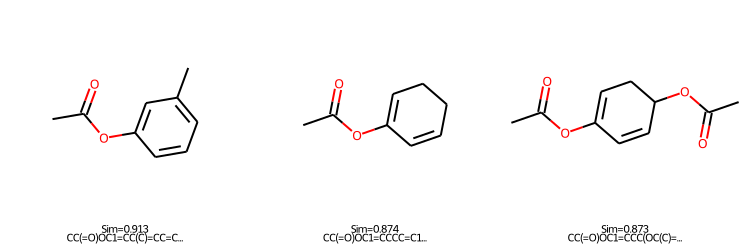

   📊 Пояснение: показаны топ-3 уникальных кандидата с наибольшей
      косинусной схожестью с аспирином (чем выше, тем ближе в латентном пространстве).

🌡️ Температура 0.7:
   1. Схожесть: 0.9363 | CC(=O)OC1=CC=CC=C1
   2. Схожесть: 0.9190 | CC(=O)OC1=CC=C(C)C=C1
   3. Схожесть: 0.9168 | CC(=O)OC1=CC(C(=O)O)=CC=C1


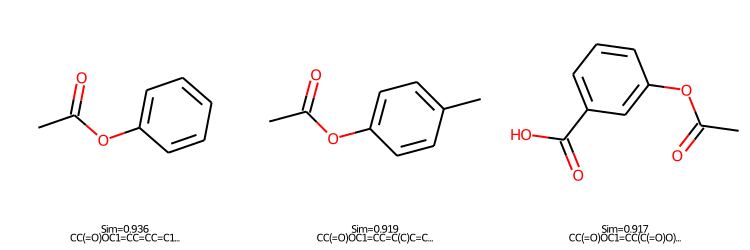

   📊 Пояснение: показаны топ-3 уникальных кандидата с наибольшей
      косинусной схожестью с аспирином (чем выше, тем ближе в латентном пространстве).


[15:33:23] WARNING: not removing hydrogen atom without neighbors
[15:33:23] WARNING: not removing hydrogen atom without neighbors
[15:33:23] WARNING: not removing hydrogen atom without neighbors
[15:33:23] WARNING: not removing hydrogen atom without neighbors



🌡️ Температура 1.5:
   1. Схожесть: 0.9208 | CC(=O)OC1=CCC=CC1=N
   2. Схожесть: 0.9200 | CC(=O)OC1=CC=CC=C1C
   3. Схожесть: 0.9199 | CC(=O)OC1=CC=CC=C1


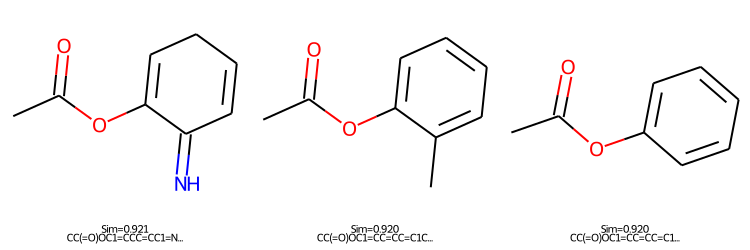

   📊 Пояснение: показаны топ-3 уникальных кандидата с наибольшей
      косинусной схожестью с аспирином (чем выше, тем ближе в латентном пространстве).

ВЫВОДЫ ПО ТЕМПЕРАТУРАМ:

• Низкая температура (0.2): более детерминированные генерации,
  меньше уникальных молекул, но выше внутригрупповая схожесть

• Средняя температура (0.7): баланс между разнообразием и валидностью

• Высокая температура (1.5): максимальное разнообразие,
  но больше невалидных SMILES и ниже внутригрупповая схожесть



In [23]:
# Анализ: уникальность и средняя внутренняя схожесть
from sklearn.metrics.pairwise import cosine_similarity

def analyze(smiles_list):
    embs = []
    valids = []
    seen_smiles = set()  # для отслеживания уникальных SMILES
    
    for s in smiles_list:
        if Chem.MolFromSmiles(s):
            # Канонизируем SMILES для сравнения уникальности
            canon_s = Chem.MolToSmiles(Chem.MolFromSmiles(s))
            if canon_s not in seen_smiles:
                seen_smiles.add(canon_s)
                emb, *_ = get_embedding_and_tokens_v2(s)
                embs.append(emb)
                valids.append(s)  # сохраняем оригинальную SMILES для отображения
    
    if not embs:
        return {'n_valid':0, 'n_unique':0, 'mean_similarity':None, 'valids':[]}
    
    embs = np.vstack(embs)
    simm = cosine_similarity(embs)
    n = simm.shape[0]
    mean_sim = (simm.sum() - np.trace(simm)) / (n*(n-1)) if n>1 else 1.0
    
    return {
        'n_valid': len(valids), 
        'n_unique': len(set(valids)), 
        'mean_similarity': mean_sim, 
        'valids': valids
    }

analysis = {t: analyze(results[t]['valid']) for t in temps}

# Компактный вывод анализа
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ АНАЛИЗА ГЕНЕРАЦИИ")
print("="*60)

for t in temps:
    stats = analysis[t]
    print(f"\n🌡️ Температура {t}:")
    print(f"   Валидных: {stats['n_valid']}")
    print(f"   Уникальных: {stats['n_unique']}")
    print(f"   Средняя внутригрупповая схожесть: {stats['mean_similarity']:.3f}")

# Показ лучших кандидатов по схожести с aspirin
asp_emb, *_ = get_embedding_and_tokens_v2(molecules['aspirin'])

def sim_to_asp(s):
    emb, *_ = get_embedding_and_tokens_v2(s)
    return cosine_similarity(asp_emb.reshape(1,-1), emb.reshape(1,-1))[0,0]

print("\n" + "="*60)
print("ЛУЧШИЕ КАНДИДАТЫ (ТОП-3 ПО СХОЖЕСТИ С АСПИРИНОМ)")
print("="*60)

for t in temps:
    valids = analysis[t]['valids']
    
    if valids:
        # Оставляем только уникальные и сортируем
        unique_valids = []
        seen = set()
        for s in valids:
            canon_s = Chem.MolToSmiles(Chem.MolFromSmiles(s))
            if canon_s not in seen:
                seen.add(canon_s)
                unique_valids.append(s)
        
        # Сортируем по схожести и берем топ-3
        scored = sorted([(s, sim_to_asp(s)) for s in unique_valids], 
                       key=lambda x: x[1], reverse=True)[:3]
        
        print(f"\n🌡️ Температура {t}:")
        for i, (s, sim) in enumerate(scored, 1):
            print(f"   {i}. Схожесть: {sim:.4f} | {s}")
        
        # Отрисовываем молекулы
        mols = [Chem.MolFromSmiles(s) for s,_ in scored]
        legends = [f"Sim={sim:.3f}\n{s[:20]}..." for s,sim in scored]
        
        if mols and any(mols):
            img = Draw.MolsToGridImage(
                [m for m in mols if m is not None],
                molsPerRow=3,
                subImgSize=(250, 250),
                legends=[legends[i] for i, m in enumerate(mols) if m is not None]
            )
            display(img)
            
            print(f'   📊 Пояснение: показаны топ-3 уникальных кандидата с наибольшей\n'
                  f'      косинусной схожестью с аспирином (чем выше, тем ближе в латентном пространстве).')
    else:
        print(f"\n🌡️ Температура {t}: нет валидных кандидатов")

print("\n" + "="*60)
print("ВЫВОДЫ ПО ТЕМПЕРАТУРАМ:")
print("="*60)
print(f"""
• Низкая температура ({temps[0]}): более детерминированные генерации,
  меньше уникальных молекул, но выше внутригрупповая схожесть

• Средняя температура ({temps[1]}): баланс между разнообразием и валидностью

• Высокая температура ({temps[2]}): максимальное разнообразие,
  но больше невалидных SMILES и ниже внутригрупповая схожесть
""")

[15:24:40] WARNING: not removing hydrogen atom without neighbors


{0.2: {'n_valid': 100, 'n_unique': 10, 'mean_similarity': 0.8987778172348485, 'valids': ['CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCC(C)=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCCC1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CC(C)CC1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CC(C)C=C1', 'CC(=O)OC1=CCCC1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCC(C)=C1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CCCC1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CC(C)C=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCC(C)=C1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CC(C)(C)CC1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CC(C)=CC=C1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CC(C)(C)C=C1', 'CC(=O)OC1=CCCC1', 'CC(=O)OC1=CCC=C1', 'CC(=O)OC1=CCCC1', 'CC

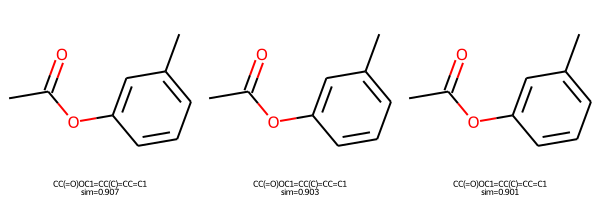

Пояснение (сетка, temp=0.2): легенда показывает SMILES и косинусную схожесть с aspirin — чем выше, тем ближе в латентном пространстве.


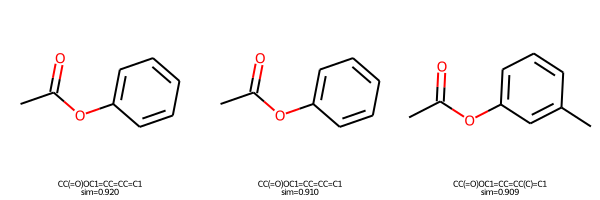

Пояснение (сетка, temp=0.7): легенда показывает SMILES и косинусную схожесть с aspirin — чем выше, тем ближе в латентном пространстве.


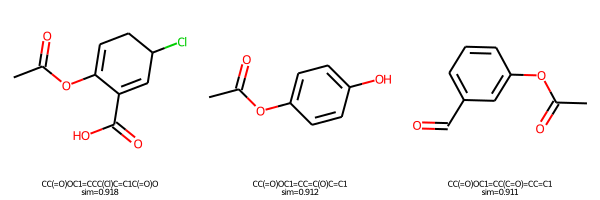

Пояснение (сетка, temp=1.5): легенда показывает SMILES и косинусную схожесть с aspirin — чем выше, тем ближе в латентном пространстве.


In [20]:
# Анализ: уникальность и средняя внутренняя схожесть
from sklearn.metrics.pairwise import cosine_similarity

def analyze(smiles_list):
    embs = []
    valids = []
    for s in smiles_list:
        if Chem.MolFromSmiles(s):
            emb, *_ = get_embedding_and_tokens_v2(s)
            embs.append(emb)
            valids.append(s)
    if not embs:
        return {'n_valid':0, 'n_unique':0, 'mean_similarity':None, 'valids':[]}
    embs = np.vstack(embs)
    simm = cosine_similarity(embs)
    n = simm.shape[0]
    mean_sim = (simm.sum() - np.trace(simm)) / (n*(n-1)) if n>1 else 1.0
    return {'n_valid':len(valids), 'n_unique':len(set(valids)), 'mean_similarity':mean_sim, 'valids':valids}

analysis = {t: analyze(results[t]['valid']) for t in temps}
print(analysis)

# Показ лучших кандидатов по схожести с aspirin
asp_emb, *_ = get_embedding_and_tokens_v2(molecules['aspirin'])

def sim_to_asp(s):
    emb, *_ = get_embedding_and_tokens_v2(s)
    return cosine_similarity(asp_emb.reshape(1,-1), emb.reshape(1,-1))[0,0]

for t in temps:
    valids = analysis[t]['valids']
    scored = sorted([(s, sim_to_asp(s)) for s in valids], key=lambda x: x[1], reverse=True)[:3]
    mols = [Chem.MolFromSmiles(s) for s,_ in scored]
    legends = [f"{s}\nsim={sim:.3f}" for s,sim in scored]
    if mols:
        display(Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200,200), legends=legends))
        print(f'Пояснение (сетка, temp={t}): легенда показывает SMILES и косинусную схожесть с aspirin — чем выше, тем ближе в латентном пространстве.')
    else:
        print(f'Нет валидных кандидатов для temp={t}')

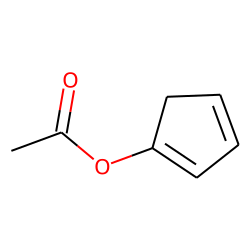

In [61]:

fragment_valid = 'CC(=O)OC1=CC=CC1'  # валидный бензольный фрагмент

from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles(fragment_valid)
img = Draw.MolToImage(mol, size=(250,250))
display(img)

Temp=0.2: generated=500, valid=500, unique_valid=14
Temp=0.7: generated=500, valid=500, unique_valid=213


[16:15:24] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 14 15 16 17 18
[16:15:24] WARNING: not removing hydrogen atom without neighbors
[16:15:24] WARNING: not removing hydrogen atom without neighbors
[16:15:24] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 15
[16:15:24] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 18 23 24 25 26 27 30 31 33
[16:15:24] SMILES Parse Error: unclosed ring for input: 'CC(=O)OC1=CC=N'
[16:15:24] SMILES Parse Error: unclosed ring for input: 'CC(=O)OC1=CCOc2c3nc4[nH+]c(nc5c4[n-]c(nc6nc(nc2[n-]3)[n-]6)-c2ccc(cc2-6)N1C1NC2=[N+](N3C12c1ccccc2C(=O)c2ccccc21)c1ccccc1-5)OC(C(O)c1ccccc1)[n+]1c3ccccc21.[OH3+]'
[16:15:24] Explicit valence for atom # 18 C, 5, is greater than permitted
[16:15:24] Explicit valence for atom # 8 O, 3, is greater than permitted
[16:15:24] Explicit valence for atom # 21 N, 4, is greater than permitted
[16:15:24] Explicit valence for atom # 14 C, 5, is greater than permitted
[16:15:24] SMILES Parse Error: unclosed ring fo

Temp=1.5: generated=500, valid=440, unique_valid=361

РЕЗУЛЬТАТЫ АНАЛИЗА ГЕНЕРАЦИИ

🌡️ Температура 0.2:
   Валидных: 500
   Уникальных: 14
   Средняя внутригрупповая схожесть: 0.897

🌡️ Температура 0.7:
   Валидных: 500
   Уникальных: 213
   Средняя внутригрупповая схожесть: 0.844

🌡️ Температура 1.5:
   Валидных: 440
   Уникальных: 361
   Средняя внутригрупповая схожесть: 0.761

ЛУЧШИЕ КАНДИДАТЫ (ТОП-3 ПО СХОЖЕСТИ С АСПИРИНОМ)


**🌡️ Температура 0.2 | Валидных: 500 | Уникальных: 14**

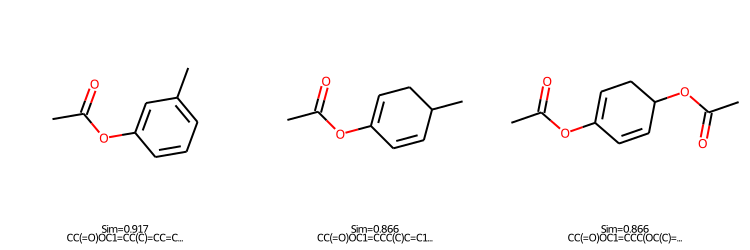

   📊 Пояснение: топ-3 уникальных кандидата с наибольшей косинусной схожестью с аспирином


**🌡️ Температура 0.7 | Валидных: 500 | Уникальных: 213**

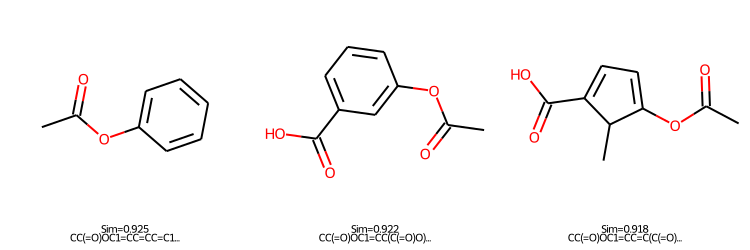

   📊 Пояснение: топ-3 уникальных кандидата с наибольшей косинусной схожестью с аспирином


**🌡️ Температура 1.5 | Валидных: 440 | Уникальных: 361**

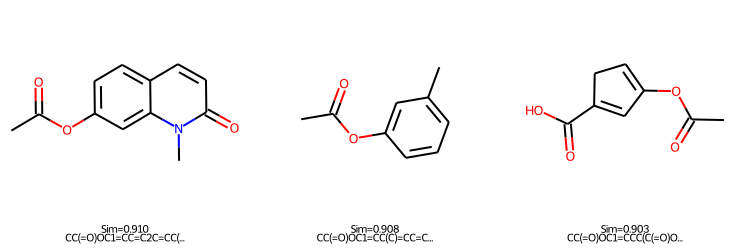

   📊 Пояснение: топ-3 уникальных кандидата с наибольшей косинусной схожестью с аспирином

ВЫВОДЫ ПО ТЕМПЕРАТУРАМ:

• Низкая температура (0.2): более детерминированные генерации,
  меньше уникальных молекул, но выше внутригрупповая схожесть

• Средняя температура (0.7): баланс между разнообразием и валидностью

• Высокая температура (1.5): максимальное разнообразие,
  но больше невалидных SMILES и ниже внутригрупповая схожесть



In [62]:
# ===============================
# Функция генерации SMILES
# ===============================
def generate_smiles(fragment, batch_size=20, temperature=1.0, max_length=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if max_length is None:
        try:
            max_length = gen_model.config.max_position_embeddings
        except Exception:
            max_length = 256

    inputs = tokenizer(fragment, return_tensors='pt').to(device)
    with torch.no_grad():
        out = gen_model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            max_length=max_length,
            num_return_sequences=batch_size,
            pad_token_id=tokenizer.eos_token_id
        ).cpu()

    decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
    cleaned = [d.strip().split()[0] for d in decoded if isinstance(d, str) and d.strip()]
    return cleaned

# ===============================
# Функция проверки валидности
# ===============================
def is_valid_smiles(s):
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return False
    try:
        Chem.SanitizeMol(mol)  # проверка валентности и базовой корректности
        return True
    except:
        return False

# ===============================
# Генерация на разных температурах
# ===============================
fragment = 'CC(=O)OC1=CC'
# fragment = 'c1ccccc1'
# fragment = 'CC(=O)OC'
temps = [0.2, 0.7, 1.5]
results = {}

for t in temps:
    gen = generate_smiles(fragment, batch_size=500, temperature=t, seed=42)
    
    # Фильтрация валидных молекул
    valid = [s for s in gen if is_valid_smiles(s)]
    
    # Канонизация для уникальности
    canon_seen = set()
    unique_valid = []
    for s in valid:
        canon_s = Chem.MolToSmiles(Chem.MolFromSmiles(s))
        if canon_s not in canon_seen:
            canon_seen.add(canon_s)
            unique_valid.append(s)
    
    results[t] = {'raw': gen, 'valid': valid, 'unique_valid': unique_valid}
    
    print(f"Temp={t}: generated={len(gen)}, valid={len(valid)}, unique_valid={len(unique_valid)}")

# ===============================
# Анализ схожести с aspirin
# ===============================
asp_emb, *_ = get_embedding_and_tokens_v2(molecules['aspirin'])

def sim_to_asp(s):
    emb, *_ = get_embedding_and_tokens_v2(s)
    return cosine_similarity(asp_emb.reshape(1,-1), emb.reshape(1,-1))[0,0]

# ===============================
# Компактный вывод анализа
# ===============================
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ АНАЛИЗА ГЕНЕРАЦИИ")
print("="*60)

for t in temps:
    stats = results[t]
    # Средняя внутригрупповая схожесть
    embs = []
    for s in stats['unique_valid']:
        emb, *_ = get_embedding_and_tokens_v2(s)
        embs.append(emb)
    if embs:
        embs = np.vstack(embs)
        simm = cosine_similarity(embs)
        n = simm.shape[0]
        mean_sim = (simm.sum() - np.trace(simm)) / (n*(n-1)) if n>1 else 1.0
    else:
        mean_sim = None

    print(f"\n🌡️ Температура {t}:")
    print(f"   Валидных: {len(stats['valid'])}")
    print(f"   Уникальных: {len(stats['unique_valid'])}")
    if mean_sim is not None:
        print(f"   Средняя внутригрупповая схожесть: {mean_sim:.3f}")
    else:
        print(f"   Средняя внутригрупповая схожесть: -")

# ===============================
# Показ топ-3 кандидатов по схожести с aspirin
# ===============================
from IPython.display import display, Markdown

# ===============================
# Показ топ-3 кандидатов по схожести с aspirin с подписью
# ===============================
print("\n" + "="*60)
print("ЛУЧШИЕ КАНДИДАТЫ (ТОП-3 ПО СХОЖЕСТИ С АСПИРИНОМ)")
print("="*60)

for t in temps:
    unique_valids = results[t]['unique_valid']
    if unique_valids:
        scored = sorted([(s, sim_to_asp(s)) for s in unique_valids], key=lambda x: x[1], reverse=True)[:3]
        
        n_valid = len(results[t]['valid'])
        n_unique = len(unique_valids)
        
        # подпись сверху
        display(Markdown(f"**🌡️ Температура {t} | Валидных: {n_valid} | Уникальных: {n_unique}**"))
        
        mols = [Chem.MolFromSmiles(s) for s,_ in scored]
        legends = [f"Sim={sim:.3f}\n{s[:20]}..." for s,sim in scored]
        if mols and any(mols):
            img = Draw.MolsToGridImage(
                [m for m in mols if m is not None],
                molsPerRow=3,
                subImgSize=(250, 250),
                legends=[legends[i] for i, m in enumerate(mols) if m is not None]
            )
            display(img)
            print(f'   📊 Пояснение: топ-3 уникальных кандидата с наибольшей косинусной схожестью с аспирином')
    else:
        display(Markdown(f"🌡️ Температура {t}: нет валидных кандидатов"))

# ===============================
# Выводы по температурам
# ===============================
print("\n" + "="*60)
print("ВЫВОДЫ ПО ТЕМПЕРАТУРАМ:")
print("="*60)
print(f"""
• Низкая температура ({temps[0]}): более детерминированные генерации,
  меньше уникальных молекул, но выше внутригрупповая схожесть

• Средняя температура ({temps[1]}): баланс между разнообразием и валидностью

• Высокая температура ({temps[2]}): максимальное разнообразие,
  но больше невалидных SMILES и ниже внутригрупповая схожесть
""")

# 12. Заключение, преимущества и ограничения

**Ключевые выводы:**

- **Что делает MoLFormer:** кодирует SMILES в плотные векторы (эмбеддинги) и может генерировать новые SMILES с causal LM.
- **Преимущества:** способность работать с большим химическим пространством, извлекать структурные закономерности, быстрый поиск аналогов в латентном пространстве.
- **Ограничения:** эмбеддинги отражают структуру SMILES, но не гарантируют биологическую активность; модель не заменяет экспериментальную проверку; генерация требует фильтрации (валидность, токсичность, синтезируемость).